In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt



In [38]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [39]:
import seaborn as sns
sns.set()

In [40]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
INFILE = "C:\\Users\\roadsafe\\Documents\\Grad School\\MSDS 422 - Machine Learning\\HMEQ_Loss.csv"

df = pd.read_csv(INFILE)

In [41]:
df.describe()


,TARGET_BAD_FLAG,TARGET_LOSS_AMT,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,1189.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,13414.576955,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,10839.455965,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,224.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,5639.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,11003.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,17634.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,78987.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


In [42]:
# print(df.head())

print(df.head(3).T)

                         0           1           2
TARGET_BAD_FLAG          1           1           1
TARGET_LOSS_AMT      641.0      1109.0       767.0
LOAN                  1100        1300        1500
MORTDUE            25860.0     70053.0     13500.0
VALUE              39025.0     68400.0     16700.0
REASON             HomeImp     HomeImp     HomeImp
JOB                  Other       Other       Other
YOJ                   10.5         7.0         4.0
DEROG                  0.0         0.0         0.0
DELINQ                 0.0         2.0         0.0
CLAGE            94.366667  121.833333  149.466667
NINQ                   1.0         0.0         1.0
CLNO                   9.0        14.0        10.0
DEBTINC                NaN         NaN         NaN


In [43]:
## Find the variables that are objects, integers, and floats. Put them in a list.

# print(df.dtypes)
dt = df.dtypes
print(dt)
# print(df.describe().T)

objList = []
intList = []
floatList = []


TARGET_F = "TARGET_BAD_FLAG"
TARGET_A = "TARGET_LOSS_AMT"

for i in dt.index:
    # print(" here is i ....", i, ".... and here is the type", dt[i])
    if i in ( [TARGET_F, TARGET_A] ): continue
    if dt[i] in (["object"]) : objList.append(i)
    if dt[i] in (["float64"]) : floatList.append(i)
    if dt[i] in (["int64"]) : intList.append(i)

# print(" OBJECTS ")
# print('  ------ ')
# for i in objList:
#     print(i)
# print(" INTEGERS ")
# print('  ------ '\n)
# for i in intList:
#     print(i)
# print(" FLOAT ")
# print('  ------ ')
# for i in floatList:
#     print(i)


### Explore the Categorical / Object Variables
# for i in objList:
#         print(" Class = ", i)
#         g = df.groupby(i)
#         # print(g[i].count())
#         x = g[TARGET_F].mean()
#         print('Loan Owed = ', x)
#         print(" ---------- ")
#         x = g[TARGET_A].mean()
#         print('Remaining  Amount = ', x)
#         print(' =============\n\n\n')




TARGET_BAD_FLAG      int64
TARGET_LOSS_AMT    float64
LOAN                 int64
MORTDUE            float64
VALUE              float64
REASON              object
JOB                 object
YOJ                float64
DEROG              float64
DELINQ             float64
CLAGE              float64
NINQ               float64
CLNO               float64
DEBTINC            float64
dtype: object


In [44]:
##'''
##EXPLORE THE CONTINUOUS VARIABLES
##'''
print("\n\n")
print("INTEGER VARIABLES" )
print("\n")
for i in intList :
   print("Variable=",i )
   g = df.groupby( TARGET_F )
   x = g[ i ].mean()
   print( "Loan Prob", x )
   c = df[i].corr( df[ TARGET_A ] )
   c = round( 100*c, 1 )
   print( "Delinq Correlation = ", c, "%" )
   print(" ===============\n\n\n ")





INTEGER VARIABLES


Variable= LOAN
Loan Prob TARGET_BAD_FLAG
0    19028.107315
1    16922.119428
Name: LOAN, dtype: float64
Delinq Correlation =  83.7 %


 


In [45]:
print("\n\n")
print("FLOAT VARIABLES" )
print("\n")
for i in floatList :
   print("Variable=",i )
   g = df.groupby( TARGET_F )
   x = g[ i ].mean()
   print( "Loan Amount Prob", x )
   c = df[i].corr( df[ TARGET_A ] )
   c = round( 100*c, 1 )
   print( "Delinq Correlation = ", c, "%" )
   print(" ===============\n\n\n ")




FLOAT VARIABLES


Variable= MORTDUE
Loan Amount Prob TARGET_BAD_FLAG
0    74829.249055
1    69460.452973
Name: MORTDUE, dtype: float64
Delinq Correlation =  34.9 %


 
Variable= VALUE
Loan Amount Prob TARGET_BAD_FLAG
0    102595.921018
1     98172.846227
Name: VALUE, dtype: float64
Delinq Correlation =  36.7 %


 
Variable= YOJ
Loan Amount Prob TARGET_BAD_FLAG
0    9.154941
1    8.027802
Name: YOJ, dtype: float64
Delinq Correlation =  1.8 %


 
Variable= DEROG
Loan Amount Prob TARGET_BAD_FLAG
0    0.134217
1    0.707804
Name: DEROG, dtype: float64
Delinq Correlation =  9.5 %


 
Variable= DELINQ
Loan Amount Prob TARGET_BAD_FLAG
0    0.245133
1    1.229185
Name: DELINQ, dtype: float64
Delinq Correlation =  22.7 %


 
Variable= CLAGE
Loan Amount Prob TARGET_BAD_FLAG
0    187.002355
1    150.190183
Name: CLAGE, dtype: float64
Delinq Correlation =  1.4 %


 
Variable= NINQ
Loan Amount Prob TARGET_BAD_FLAG
0    1.032749
1    1.782765
Name: NINQ, dtype: float64
Delinq Correlation =  14.3 

REASON
['DebtCon', 'HomeImp', nan]
[3928, 1780, 252]


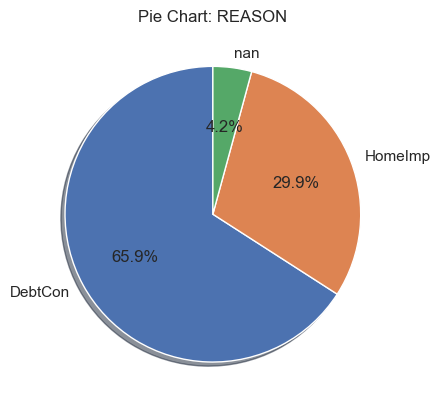

=====


JOB
['Other', 'ProfExe', 'Office', 'Mgr', nan, 'Self', 'Sales']
[2388, 1276, 948, 767, 279, 193, 109]


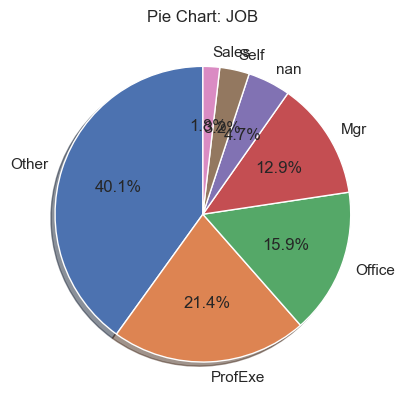

=====




In [46]:
### Pie Charts

for i in objList :
   print(i)
   x = df[ i ].value_counts(dropna=False)
   #print( x )
   theLabels = x.axes[0].tolist()
   print( theLabels )
   theSlices = list(x)
   print( theSlices )
   plt.pie( theSlices,
            labels=theLabels,
            startangle = 90,
            shadow=True,
            autopct="%1.1f%%")
   plt.title("Pie Chart: " + i)
   plt.show()
   print("=====\n\n")


['DebtCon', 'HomeImp', nan]
[3928, 1780, 252]
[0, 0.1, 0.3]


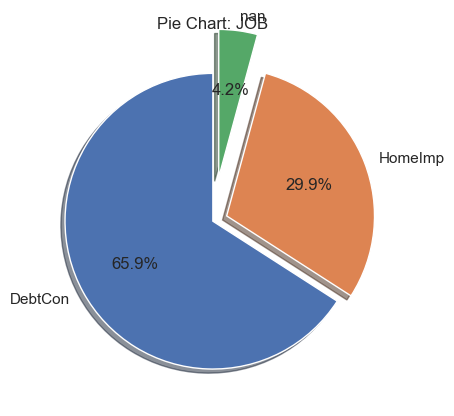

In [47]:
x = df["REASON"].value_counts(dropna=False)
theLabels = x.axes[0].tolist()
theSlices = list(x)
explodeList = [ 0 for i in theSlices ]
explodeList[1] = 0.1
explodeList[2] = 0.3
print( theLabels )
print( theSlices )
print( explodeList )
plt.pie( theSlices,
         labels=theLabels,
         startangle = 90,
         explode=explodeList,
         shadow=True,
         autopct="%1.1f%%")
plt.title("Pie Chart: " + i)
plt.show()

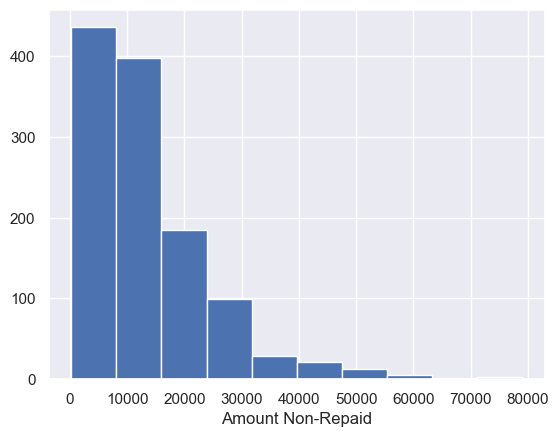

In [48]:
##for i in intList :
##    plt.hist( df[ i ] )
##    plt.xlabel( i )
##    plt.show()

# for i in floatList :
#     plt.hist( df[ i ] )
#     plt.xlabel( i )
#     plt.show()

plt.hist( df[ TARGET_A ] )
plt.xlabel( "Amount Non-Repaid" )
plt.show()



## Part 2


In [49]:
objList = []
numList = []
for i in dt.index :
    #print(" here is i .....", i , " ..... and here is the type", dt[i] )
    if i in ( [ TARGET_F, TARGET_A ] ) : continue
    if dt[i] in (["object"]) : objList.append( i )
    if dt[i] in (["float64","int64"]) : numList.append( i )


In [50]:
print(" OBJECTS ")
print(" ------- ")
for i in objList :
   print( i )
print(" ------- ")



print(" NUMBER ")
print(" ------- ")
for i in numList :
   print( i )
print(" ------- ")

 OBJECTS 
 ------- 
REASON
JOB
 ------- 
 NUMBER 
 ------- 
LOAN
MORTDUE
VALUE
YOJ
DEROG
DELINQ
CLAGE
NINQ
CLNO
DEBTINC
 ------- 


In [51]:
### identifying the missing

for i in objList :
        print(i)
        print( df[i].unique())
        g = df.groupby(i)
        print( g[i].count())
        print( "Most Common = ", df[i].mode()[0])
        print( "Missing = ", df[i].isna().sum())

REASON
['HomeImp' nan 'DebtCon']
REASON
DebtCon    3928
HomeImp    1780
Name: REASON, dtype: int64
Most Common =  DebtCon
Missing =  252
JOB
['Other' nan 'Office' 'Sales' 'Mgr' 'ProfExe' 'Self']
JOB
Mgr         767
Office      948
Other      2388
ProfExe    1276
Sales       109
Self        193
Name: JOB, dtype: int64
Most Common =  Other
Missing =  279


In [52]:
for i in objList :
   if df[i].isna().sum() == 0 : continue
   print( i )


REASON
JOB


In [53]:

### FILL IN MISSING WITH THE CATEGORY "MISSING"

for i in objList :
   if df[i].isna().sum() == 0 : continue
   NAME = "IMP_"+i
   df[NAME] = df[i]
   df[NAME] = df[NAME].fillna("MISSING")
   g = df.groupby( NAME )
   df = df.drop( i, axis=1 )


dt = df.dtypes
objList = []
for i in dt.index :
   #print(" here is i .....", i , " ..... and here is the type", dt[i] )
   if i in ( [ TARGET_F, TARGET_A ] ) : continue
   if dt[i] in (["object"]) : objList.append( i )


In [54]:
# for i in objList :
#    if df[i].isna().sum() == 0 : continue
#    print(i)
#    print("Has Missing")
#    NAME = "IMP_" +i
#    print(NAME)
#    df[NAME] = df[i]
#    df[NAME] = df[NAME].fillna(df[NAME].mode()[0])
#    print('variable',i," has this many missing", df[i].isna().sum())
#    print('variable',NAME," has this many missing", df[NAME].isna().sum())
#    g = df.groupby(NAME)
#    print( g[NAME].count())
#    print("\n\n")
#    df = df.drop(i, axis=1)

In [55]:
print(df.head(3).T)

                         0           1           2
TARGET_BAD_FLAG          1           1           1
TARGET_LOSS_AMT      641.0      1109.0       767.0
LOAN                  1100        1300        1500
MORTDUE            25860.0     70053.0     13500.0
VALUE              39025.0     68400.0     16700.0
YOJ                   10.5         7.0         4.0
DEROG                  0.0         0.0         0.0
DELINQ                 0.0         2.0         0.0
CLAGE            94.366667  121.833333  149.466667
NINQ                   1.0         0.0         1.0
CLNO                   9.0        14.0        10.0
DEBTINC                NaN         NaN         NaN
IMP_REASON         HomeImp     HomeImp     HomeImp
IMP_JOB              Other       Other       Other


In [56]:
for i in ["IMP_JOB"] :
        print(i)
        print( df[i].unique())
        g = df.groupby(i)
        print( g[i].count())
        print( "Most Common = ", df[i].mode()[0])
        print( "Missing = ", df[i].isna().sum())

IMP_JOB
['Other' 'MISSING' 'Office' 'Sales' 'Mgr' 'ProfExe' 'Self']
IMP_JOB
MISSING     279
Mgr         767
Office      948
Other      2388
ProfExe    1276
Sales       109
Self        193
Name: IMP_JOB, dtype: int64
Most Common =  Other
Missing =  0


In [57]:
df["z_IMP_JOB_MISSING"] = (df.IMP_JOB.isin( ["MISSING"] ) + 0 )
df["z_IMP_JOB_Mgr"] = (df.IMP_JOB.isin( ["Mgr"] ) + 0)
df["z_IMP_JOB_Office"] = (df.IMP_JOB.isin( ["Office"] ) + 0)
df["z_IMP_JOB_Other"] = (df.IMP_JOB.isin( ["Other"] ) + 0 )
df["z_IMP_JOB_Sales"] = (df.IMP_JOB.isin( ["Sales"] ) + 0)
df["z_IMP_JOB_ProfExe"] = (df.IMP_JOB.isin( ["ProfExe"] ) + 0)
df["z_IMP_JOB_Self"] = (df.IMP_JOB.isin( ["Self"] ) + 0)
df = df.drop( "IMP_JOB", axis=1 )




##dt = df.dtypes
##objList = []
##for i in dt.index :
##    #print(" here is i .....", i , " ..... and here is the type", dt[i] )
##    if i in ( [ TARGET_F, TARGET_A ] ) : continue
##    if dt[i] in (["object"]) : objList.append( i )
##
##
##for i in objList :
##    thePrefix = "z_" + i
##    y = pd.get_dummies( df[i], prefix=thePrefix, drop_first=True )
##    #y = pd.get_dummies( df[i], prefix=thePrefix )
##    df = pd.concat( [df, y], axis=1 )
##    #df = df.drop( i, axis=1 )


In [58]:
df["z_IMP_REASON_MISSING"] = (df.IMP_REASON.isin( ["MISSING"] ) + 0 )
df["z_IMP_REASON_HomeImp"] = (df.IMP_REASON.isin( ["HomeImp"] ) + 0)
df["z_IMP_REASON_DebtCon"] = (df.IMP_REASON.isin( ["DebtCon"] ) + 0)

df = df.drop( "IMP_REASON", axis=1 )

In [59]:
dt = df.dtypes
objList = []
for i in dt.index :
   #print(" here is i .....", i , " ..... and here is the type", dt[i] )
   if i in ( [ TARGET_F, TARGET_A ] ) : continue
   if dt[i] in (["object"]) : objList.append( i )

In [60]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET_BAD_FLAG,5960.0,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
TARGET_LOSS_AMT,1189.0,13414.576955,10839.455965,224.000000,5639.000000,11003.000000,17634.000000,78987.000000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
MORTDUE,5442.0,73760.817200,44457.609458,2063.000000,46276.000000,65019.000000,91488.000000,399550.000000
VALUE,5848.0,101776.048741,57385.775334,8000.000000,66075.500000,89235.500000,119824.250000,855909.000000
YOJ,5445.0,8.922268,7.573982,0.000000,3.000000,7.000000,13.000000,41.000000
DEROG,5252.0,0.254570,0.846047,0.000000,0.000000,0.000000,0.000000,10.000000
DELINQ,5380.0,0.449442,1.127266,0.000000,0.000000,0.000000,0.000000,15.000000
CLAGE,5652.0,179.766275,85.810092,0.000000,115.116702,173.466667,231.562278,1168.233561
NINQ,5450.0,1.186055,1.728675,0.000000,0.000000,1.000000,2.000000,17.000000


In [61]:
for i in objList :
   thePrefix = "z_" + i
   y = pd.get_dummies( df[i], prefix=thePrefix, drop_first=True )
   #y = pd.get_dummies( df[i], prefix=thePrefix )
   df = pd.concat( [df, y], axis=1 )
   #df = df.drop( i, axis=1 )

## Part 3 - Numerical Cleaning

In [62]:
### identifying the missing

for i in numList :
        print(i)
        # print( df[i].unique())
        # g = df.groupby(i)
        # print( g[i].count())
        # print( "Most Common = ", df[i].mode()[0])
        print( "Missing = ", df[i].isna().sum())

LOAN
Missing =  0
MORTDUE
Missing =  518
VALUE
Missing =  112
YOJ
Missing =  515
DEROG
Missing =  708
DELINQ
Missing =  580
CLAGE
Missing =  308
NINQ
Missing =  510
CLNO
Missing =  222
DEBTINC
Missing =  1267


In [63]:
for i in numList :
   if df[i].isna().sum() == 0 : continue
   FLAG = "M_" + i
   IMP = "IMP_" + i
   print(i)
   print( df[i].isna().sum() )
   print( FLAG )
   print( IMP )
   print(" ------- ")
   df[ FLAG ] = df[i].isna() + 0
   df[ IMP ] = df[ i ]
   df.loc[ df[IMP].isna(), IMP ] = df[i].median()
   df = df.drop( i, axis=1 )
##

MORTDUE
518
M_MORTDUE
IMP_MORTDUE
 ------- 
VALUE
112
M_VALUE
IMP_VALUE
 ------- 
YOJ
515
M_YOJ
IMP_YOJ
 ------- 
DEROG
708
M_DEROG
IMP_DEROG
 ------- 
DELINQ
580
M_DELINQ
IMP_DELINQ
 ------- 
CLAGE
308
M_CLAGE
IMP_CLAGE
 ------- 
NINQ
510
M_NINQ
IMP_NINQ
 ------- 
CLNO
222
M_CLNO
IMP_CLNO
 ------- 
DEBTINC
1267
M_DEBTINC
IMP_DEBTINC
 ------- 


In [64]:
g = df.groupby("z_IMP_JOB_Sales")
i = "IMP_MORTDUE"
print(g[i].median())

z_IMP_JOB_Sales
0    65019.0
1    70546.0
Name: IMP_MORTDUE, dtype: float64


In [65]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET_BAD_FLAG,5960.0,0.199497,0.399656,0.000000,0.000000,0.000000,0.000000,1.000000
TARGET_LOSS_AMT,1189.0,13414.576955,10839.455965,224.000000,5639.000000,11003.000000,17634.000000,78987.000000
LOAN,5960.0,18607.969799,11207.480417,1100.000000,11100.000000,16300.000000,23300.000000,89900.000000
z_IMP_JOB_MISSING,5960.0,0.046812,0.211254,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Mgr,5960.0,0.128691,0.334886,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Office,5960.0,0.159060,0.365763,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Other,5960.0,0.400671,0.490076,0.000000,0.000000,0.000000,1.000000,1.000000
z_IMP_JOB_Sales,5960.0,0.018289,0.134004,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_ProfExe,5960.0,0.214094,0.410227,0.000000,0.000000,0.000000,0.000000,1.000000
z_IMP_JOB_Self,5960.0,0.032383,0.177029,0.000000,0.000000,0.000000,0.000000,1.000000


### Analysis

['Paid Mortgage', 'Outstanding Mortgage']
[5193, 767]


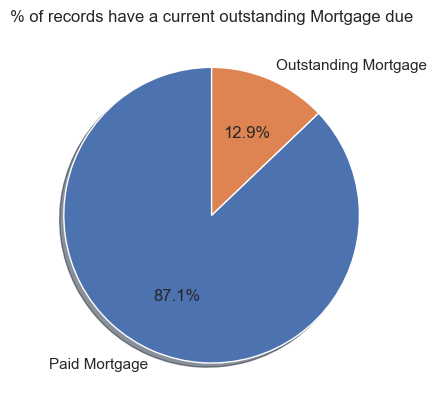

=====




In [66]:
x = df[ "z_IMP_JOB_Mgr" ].value_counts(dropna=False)
#print( x )
name_map = {1: "Outstanding Mortgage", 0: "Paid Mortgage", True: "Outstanding Mortgage", False: "Paid Mortgage", np.nan: "Missing"}
theLabels = [name_map.get(k, str(k)) for k in x.index]   # labels aligned to counts
print( theLabels )
theSlices = list(x)
print( theSlices )
plt.pie( theSlices,
        labels=theLabels,
        startangle = 90,
        shadow=True,
        autopct="%1.1f%%")
plt.title("% of records have a current outstanding Mortgage due")
plt.show()
print("=====\n\n")

### 87.1% of records have a current outstanding Mortgage due

In [69]:
out_path = r"C:\Users\roadsafe\Documents\Grad School\MSDS 422 - Machine Learning\Module 1\hmeq_assignment_1.csv"
df.to_csv(out_path, index=False, encoding="utf-8")
